In [1]:
import numpy as np
import pandas as pd
import glob
import re
import os
from plotnine import *

In [7]:
from scipy.stats import lognorm
import numpy as np

nsize = 22
minsize = 0
maxsize = 110
boundary = minsize+np.arange(0,(nsize+1),1)*(maxsize-minsize)/nsize

init_mean_adult = 3.8
init_sd_adult = 0.22


prob = (lognorm.cdf(boundary[1:(nsize+1)], s=init_sd_adult, scale=np.exp(init_mean_adult)) -
 lognorm.cdf(boundary[0:nsize], s=init_sd_adult, scale=np.exp(init_mean_adult)))

midpoints = 0.5*(boundary[0:nsize]+boundary[1:(nsize+1)])


In [8]:
midpoints

array([  2.5,   7.5,  12.5,  17.5,  22.5,  27.5,  32.5,  37.5,  42.5,
        47.5,  52.5,  57.5,  62.5,  67.5,  72.5,  77.5,  82.5,  87.5,
        92.5,  97.5, 102.5, 107.5])

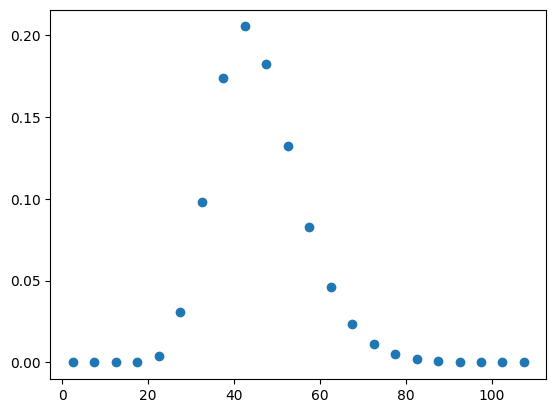

In [9]:
import matplotlib.pyplot as plt


plt.scatter(midpoints, prob)

In [7]:
# import reward simulations
csv_files = glob.glob('../data/rl_policies/**/*.csv', recursive=True)

dfs = []
for filepath in csv_files:
    filename = os.path.basename(filepath)  # e.g., 'td3_count-time_sim_3.csv'
    
    # Parse filename: {algorithm}_{obs_type}_sim_{replicate}.csv
    match = re.match(r'([^_]+)_(.+)_sim_(\d+)\.csv', filename)
    if match:
        algorithm = match.group(1)   # e.g., 'td3'
        obs_type  = match.group(2)   # e.g., 'count-time'
        replicate = int(match.group(3))  # e.g., 3
    else:
        print(f"Skipping unrecognized filename: {filename}")
        continue
    
    df = pd.read_csv(filepath)
    df = df[df['t'] == 99]  # subset by t value
    
    df['algorithm'] = algorithm
    df['obs_type']  = obs_type
    df['replicate'] = replicate
    
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

In [9]:
combined_df.head()

,t,crabs,act0,act1,rew,rep,crab_pop,nonlocal_crab,algorithm,obs_type,replicate
0,99,[-0.97785187],-1.0,-0.345478,-7.114053,0,[4.37609376e+04 2.09133795e+04 4.81668361e+00 ...,[84739.36435938 39050.52359052 55525.98560839 ...,td3,count,1
1,99,[-0.9818077],-1.0,-0.234301,-6.227104,1,[6.09840668e+03 2.91443238e+03 6.71240086e-01 ...,[84739.36435938 39050.52359052 55525.98560839 ...,td3,count,1
2,99,[-0.98249984],-1.0,-0.214102,-6.920098,2,[7.08401062e+03 3.38545312e+03 7.79723648e-01 ...,[84739.36435938 39050.52359052 55525.98560839 ...,td3,count,1
3,99,[-0.9833426],-1.0,-0.189256,-4.607659,3,[7.09249787e+03 3.38950918e+03 7.80657823e-01 ...,[84739.36435938 39050.52359052 55525.98560839 ...,td3,count,1
4,99,[-0.98141694],-1.0,-0.245617,-4.443693,4,[7.08870403e+03 3.38769611e+03 7.80240243e-01 ...,[84739.36435938 39050.52359052 55525.98560839 ...,td3,count,1


In [10]:
# 1. Group by algorithm and obs_type, mean and variance of rew
summary1 = (combined_df
    .groupby(['algorithm', 'obs_type'])['rew']
    .agg(mean_rew='mean', var_rew='var')
    .reset_index()
)

# 2. First average within each replicate, then mean and variance across replicates
summary2 = (combined_df
    .groupby(['algorithm', 'obs_type', 'replicate'])['rew']
    .mean()
    .reset_index()
    .rename(columns={'rew': 'mean_rew'})
    .groupby(['algorithm', 'obs_type'])['mean_rew']
    .agg(mean_rew='mean', var_rew='var')
    .reset_index()
)

In [11]:
summary1

,algorithm,obs_type,mean_rew,var_rew
0,ppo,count,-4.584756,2.114866
1,ppo,count-biomass-time,-4.414810,2.743945
2,ppo,count-time,-4.351580,2.492317
3,ppo,size-time,-6.338575,3.689905
4,td3,count,-7.088068,22.524514
5,td3,count-biomass-time,-4.537049,2.372257
6,td3,count-time,-5.674950,3.538274
7,td3,size-time,-11.301465,24.539137
8,tqc,count,-5.604704,2.486811
9,tqc,count-biomass-time,-3.649276,0.829079


In [12]:
summary2

,algorithm,obs_type,mean_rew,var_rew
0,ppo,count,-4.584756,0.390133
1,ppo,count-biomass-time,-4.414810,0.182153
2,ppo,count-time,-4.351580,0.244913
3,ppo,size-time,-6.338575,0.002389
4,td3,count,-7.088068,26.750554
5,td3,count-biomass-time,-4.537049,0.773654
6,td3,count-time,-5.674950,1.018121
7,td3,size-time,-11.301465,29.617358
8,tqc,count,-5.604704,1.344190
9,tqc,count-biomass-time,-3.649276,0.001837


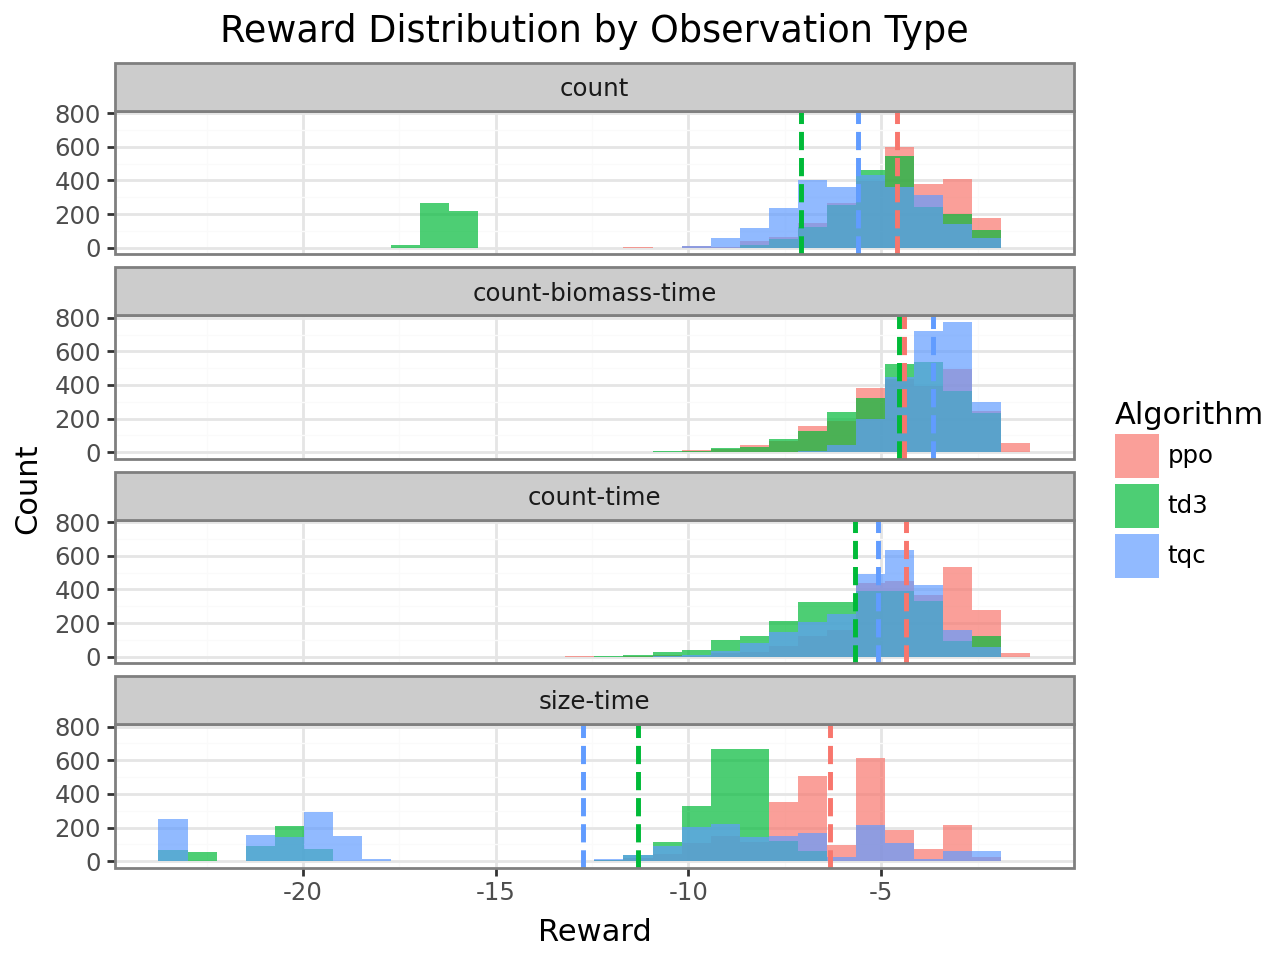

In [17]:
(
    ggplot(combined_df, aes(x='rew', fill='algorithm'))
    + geom_histogram(alpha=0.7, position='identity', bins=30)
    + facet_wrap('~obs_type', ncol=1)
    + geom_vline(data=summary1, mapping=aes(xintercept='mean_rew', color='algorithm'),
                 linetype='dashed', size=1, show_legend=False)
    + labs(x='Reward', y='Count', fill='Algorithm', title='Reward Distribution by Observation Type')
    + theme_bw()
)

In [18]:
# get best replicate
combined_df.groupby(['algorithm', 'obs_type', 'replicate'])['rew'].mean().idxmax()

('tqc', 'count-biomass-time', np.int64(3))